In [1]:
import re
from pathlib import Path
import textwrap
import torch
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers (self-contained) ----------
def _load_pt(pt_path):
    if not isinstance(pt_path, (str, Path)):
        raise TypeError(f"pt_path must be a filepath string, got {type(pt_path)}")
    data = torch.load(str(pt_path), map_location="cpu", weights_only=False)
    if not all(k in data for k in ["x", "y"]):
        raise KeyError(f"{pt_path} must contain 'x' and 'y'. Keys: {list(data.keys())}")
    return data

def _to_np(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.asarray(t)

def _parse_info_from_name(path_str):
    """从文件名里尽量解析关键信息；取不到则留空。"""
    name = Path(path_str).name
    info = {}
    # 常见字段
    m = re.search(r"solver=([A-Za-z0-9_]+)", name);         info["solver"]  = m.group(1) if m else ""
    m = re.search(r"nu([0-9eE\.\-]+)", name);               info["nu"]      = m.group(1) if m else ""
    m = re.search(r"t([0-9]+(?:\.[0-9]+)?)", name);         info["t_final"] = m.group(1) if m else ""
    m = re.search(r"norm([^\W_]+)", name);                  info["norm"]    = m.group(1) if m else ""
    m = re.search(r"alpha([0-9eE\.\-]+)", name);            info["alpha"]   = m.group(1) if m else ""
    m = re.search(r"epsilon([0-9eE\.\-]+)", name);          info["epsilon"] = m.group(1) if m else ""
    m = re.search(r"steps([0-9]+)", name);                  info["steps"]   = m.group(1) if m else ""
    m = re.search(r"N([0-9]+)", name);                      info["N"]       = m.group(1) if m else ""
    m = re.search(r"nx([0-9]+)", name);                     info["nx"]      = m.group(1) if m else ""
    return info

def _get_t_final_from_data_or_name(data, path_str):
    """优先从 pt 里的 metadata / 字段读 t_final，读不到再从文件名里解析。"""
    # 1) 常见位置：data['metadata']['t_final']
    meta = data.get("metadata", {})
    if isinstance(meta, dict):
        tf = meta.get("t_final")
        if isinstance(tf, (int, float, np.number)): return float(tf)
        # 有的存字符串
        if isinstance(tf, str):
            try: return float(tf)
            except: pass
    # 2) 有些数据直接存了 't_final'
    tf2 = data.get("t_final", None)
    if isinstance(tf2, (int, float, np.number)): return float(tf2)
    if isinstance(tf2, str):
        try: return float(tf2)
        except: pass
    # 3) 从文件名解析
    info = _parse_info_from_name(path_str)
    tf3 = info.get("t_final", "")
    try:
        return float(tf3) if tf3 else None
    except:
        return None

def _infer_times(T, t_final):
    """给 y/u 的帧生成时间数组；约定：帧是 1..T，对应 t=Δt,2Δt,...,TΔt；x=frame1；a=frame0。"""
    if t_final is None: 
        return None, None
    dt = float(t_final) / float(T)
    t_frames = [(k+1)*dt for k in range(T)]  # 1..T
    t_x = dt
    return t_x, t_frames

def _sec_str(t):
    return f"{float(t):.3g} s"

def _wrap(s: str, width: int = 30):
    """长标题自动换行。"""
    if not s: return s
    return "\n".join(textwrap.wrap(s, width=width, break_long_words=False, replace_whitespace=False))

def plot_xy_compare_attack_original_indices(
    pt_attack: str,
    pt_original: str,
    idx_list,                 # e.g. [0,3,5,7,12,18,21,23] —— 建议长度为 8
    t_idx: int = -1,          # 选择的 y/u 帧（-1 表示最后一帧）
    cmap_attack: str = "viridis",
    cmap_diff: str = "coolwarm",
    per_cell_w: float = 2.6,  # 单幅图宽度缩放
    per_cell_h: float = 2.6,  # 单幅图高度缩放
):
    """
    布局：4 行 × M 列（M=len(idx_list)）
      第 1 行：attack: x（frame 1）
      第 2 行：attack: y（frame k = t_idx%T）
      第 3 行：diff: x - a（frame 1 - frame 0）
      第 4 行：diff: y - u（frame k - frame k）
    每个子图自己的 colorbar（separate）。
    标题含 index；大标题含 attack 参数信息。
    """
    # 载入数据
    da = _load_pt(pt_attack)
    do = _load_pt(pt_original)
    x_att, y_att = da["x"], da["y"]             # attack: x=frame1, y=frames 1..T_att
    x_org, y_org = do["x"], do["y"]             # original: a=frame0, u=frames 1..T_org

    # 形状检查
    if x_att.ndim != 3 or x_org.ndim != 3:
        raise ValueError(f"x/a must be (N,H,W); got {tuple(x_att.shape)} and {tuple(x_org.shape)}")
    if y_att.ndim != 4 or y_org.ndim != 4:
        raise ValueError(f"y/u must be (N,H,W,T); got {tuple(y_att.shape)} and {tuple(y_org.shape)}")
    if x_att.shape[:3] != x_org.shape[:3]:
        raise ValueError(f"x shape mismatch: {x_att.shape} vs {x_org.shape}")

    # 帧对齐
    T_att, T_org = y_att.shape[3], y_org.shape[3]
    T = min(T_att, T_org)
    if T_att != T_org:
        print(f"[info] frame mismatch: attack T={T_att}, original T={T_org}. Use T={T} (drop extras).")
    k = t_idx % T

    # 时间标签
    info_att = _parse_info_from_name(pt_attack)
    info_org = _parse_info_from_name(pt_original)
    t_final_str = info_att.get("t_final") or info_org.get("t_final") or ""
    t_x, t_frames = _infer_times(T, t_final_str)
    t_k = t_frames[k] if t_frames is not None else None

    # 解析关键信息（大标题）
    keys_order = ["solver", "nu", "t_final", "norm", "alpha", "epsilon", "steps", "N", "nx"]
    desc_att = ", ".join([f"{k}={info_att[k]}" for k in keys_order if info_att.get(k)])
    desc_org = ", ".join([f"{k}={info_org[k]}" for k in ["solver","nu","t_final","N","nx"] if info_org.get(k)])

    # 网格尺寸
    M = len(idx_list)  # 列数
    nrows, ncols = 4, M
    figsize = (per_cell_w * ncols, per_cell_h * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    if ncols == 1:
        axes = np.array(axes).reshape(nrows, 1)

    # 逐列绘图
    for col, idx in enumerate(idx_list):
        if not (0 <= idx < x_att.shape[0]):
            raise IndexError(f"idx {idx} out of range 0..{x_att.shape[0]-1}")

        x_np = _to_np(x_att[idx])             # frame 1
        a_np = _to_np(x_org[idx])             # frame 0
        y_np = _to_np(y_att[idx, :, :, k])    # frame k
        u_np = _to_np(y_org[idx, :, :, k])    # frame k
        xd   = x_np - a_np
        yd   = y_np - u_np

        # 行 1：attack: x
        ax = axes[0, col]
        im = ax.imshow(x_np, cmap=cmap_attack)
        ax.set_title(_wrap(f"idx={idx} | attack: x\nframe 1 (t={_sec_str(t_x) if t_x is not None else 'NA'})"), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # 行 2：attack: y(k)
        ax = axes[1, col]
        im = ax.imshow(y_np, cmap=cmap_attack)
        # 附上 attack 的 loss[idx]（若存在）
        title2 = f"idx={idx} | attack: y\nframe {k+1} (t={_sec_str(t_k) if t_k is not None else 'NA'})"
        loss = da.get("loss", None)
        if isinstance(loss, torch.Tensor) and loss.ndim == 1 and idx < loss.shape[0]:
            title2 += f"\nloss={float(loss[idx]):.3e}"
        ax.set_title(_wrap(title2), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # 行 3：diff: x - a
        ax = axes[2, col]
        im = ax.imshow(xd, cmap=cmap_diff)
        t_line = (f"t={_sec_str(t_x)} − 0 s" if t_x is not None else "time aligned")
        ax.set_title(_wrap(f"idx={idx} | diff: x − a\nframe 1 − frame 0 ({t_line})"), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # 行 4：diff: y - u
        ax = axes[3, col]
        im = ax.imshow(yd, cmap=cmap_diff)
        t_line = (f"t={_sec_str(t_k)} − {_sec_str(t_k)}" if t_k is not None else "time aligned")
        ax.set_title(_wrap(f"idx={idx} | diff: y − u\nframe {k+1} − frame {k+1} ({t_line})"), fontsize=9)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 大标题（自动换行 & 抬高避免重叠）
    sup = (
        f"Attack vs Original (separate colorbars) | "
        f"attack[{desc_att}] | original[{desc_org}] | "
        f"indices={idx_list} | k={k+1}"
    )
    fig.suptitle(_wrap(sup, 120), y=1.03, fontsize=12)
    fig.subplots_adjust(top=0.88)
    return fig, axes


/tmp/ipykernel_3256267/3848171066.py:194: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


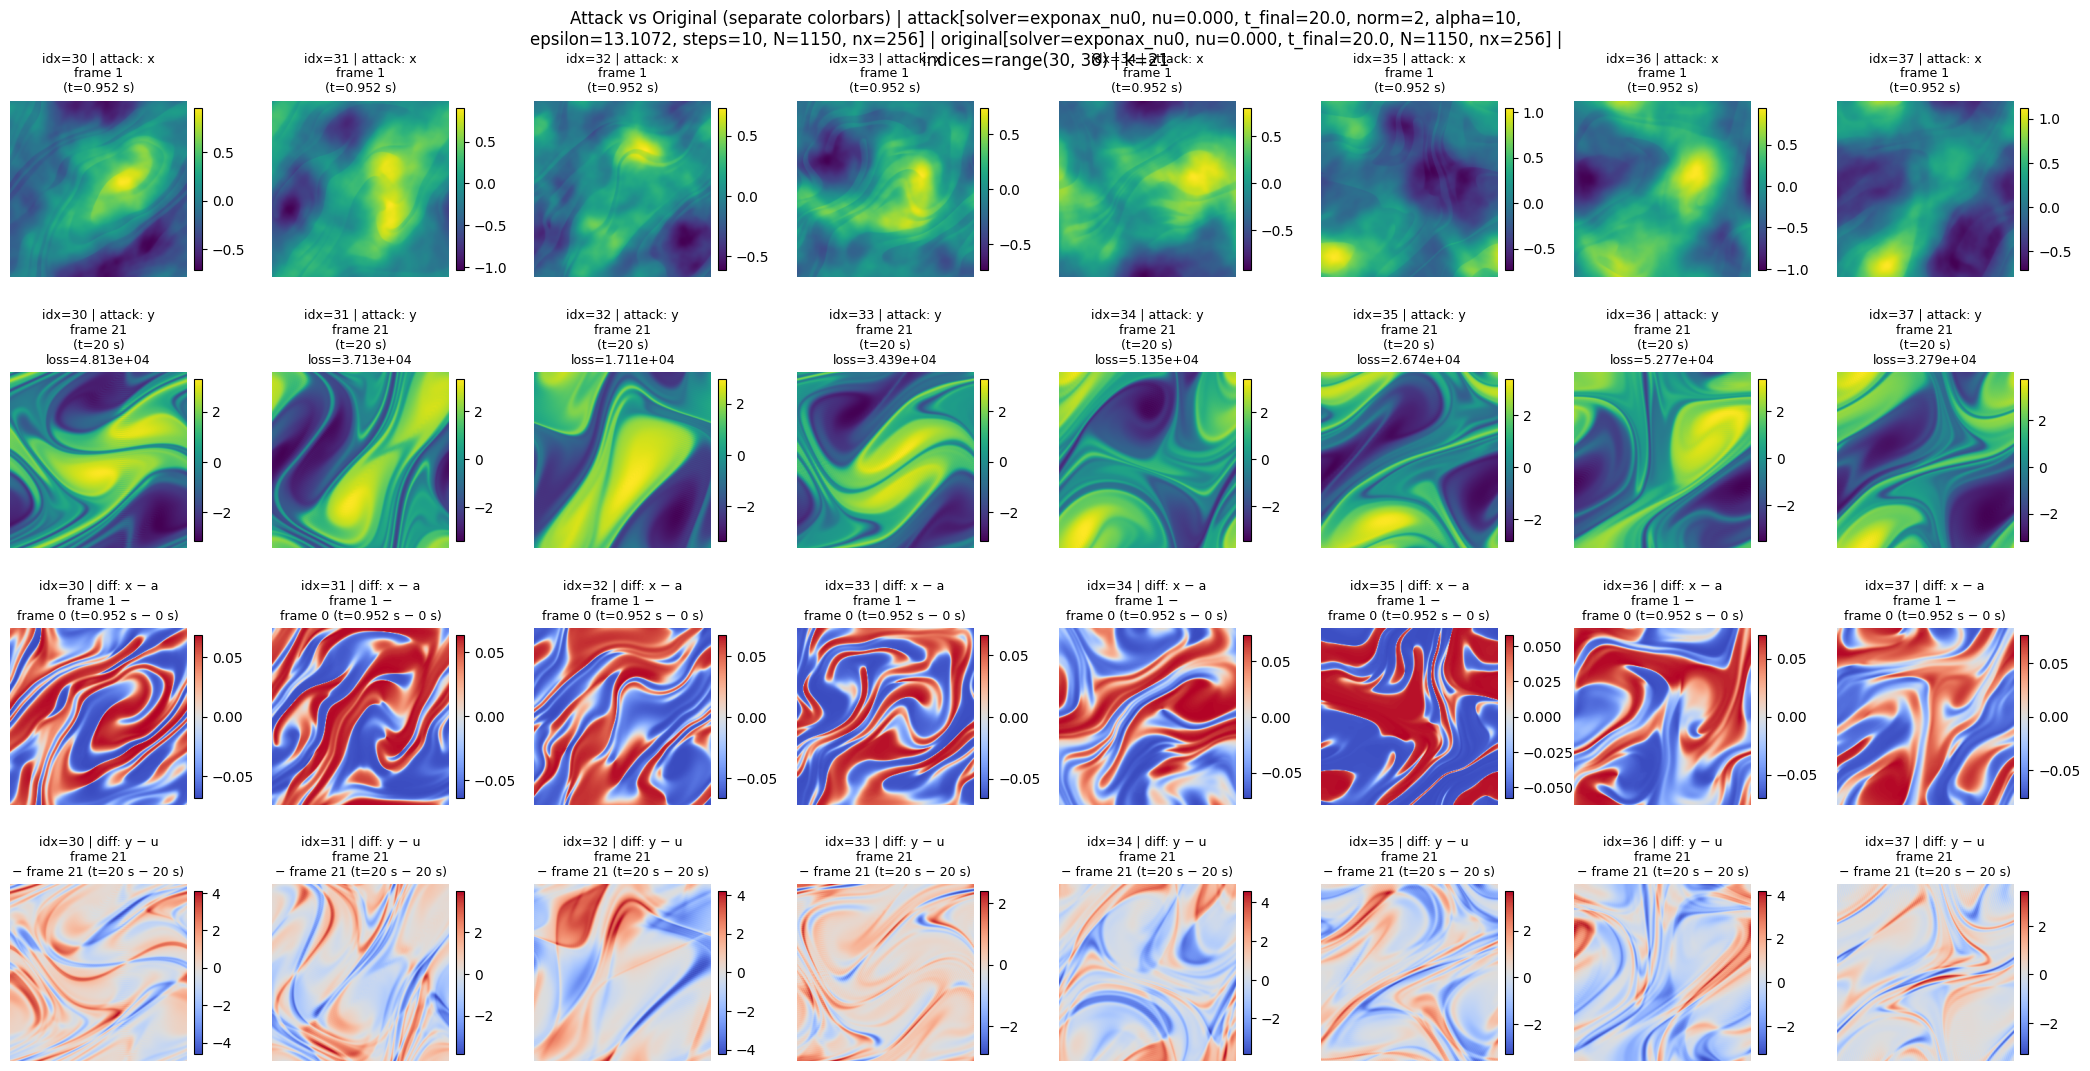

In [16]:
# pt_attack = "dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon78.6432_steps10.pt"
pt_attack = "dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon13.1072_steps10.pt"

pt_orig   = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

idxs = range(30,38)   # 8 个 index
fig, axes = plot_xy_compare_attack_original_indices(
    pt_attack, pt_orig, idx_list=idxs, t_idx=-1,
    cmap_attack="viridis", cmap_diff="coolwarm",)
plt.show()

/tmp/ipykernel_3256267/3848171066.py:194: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


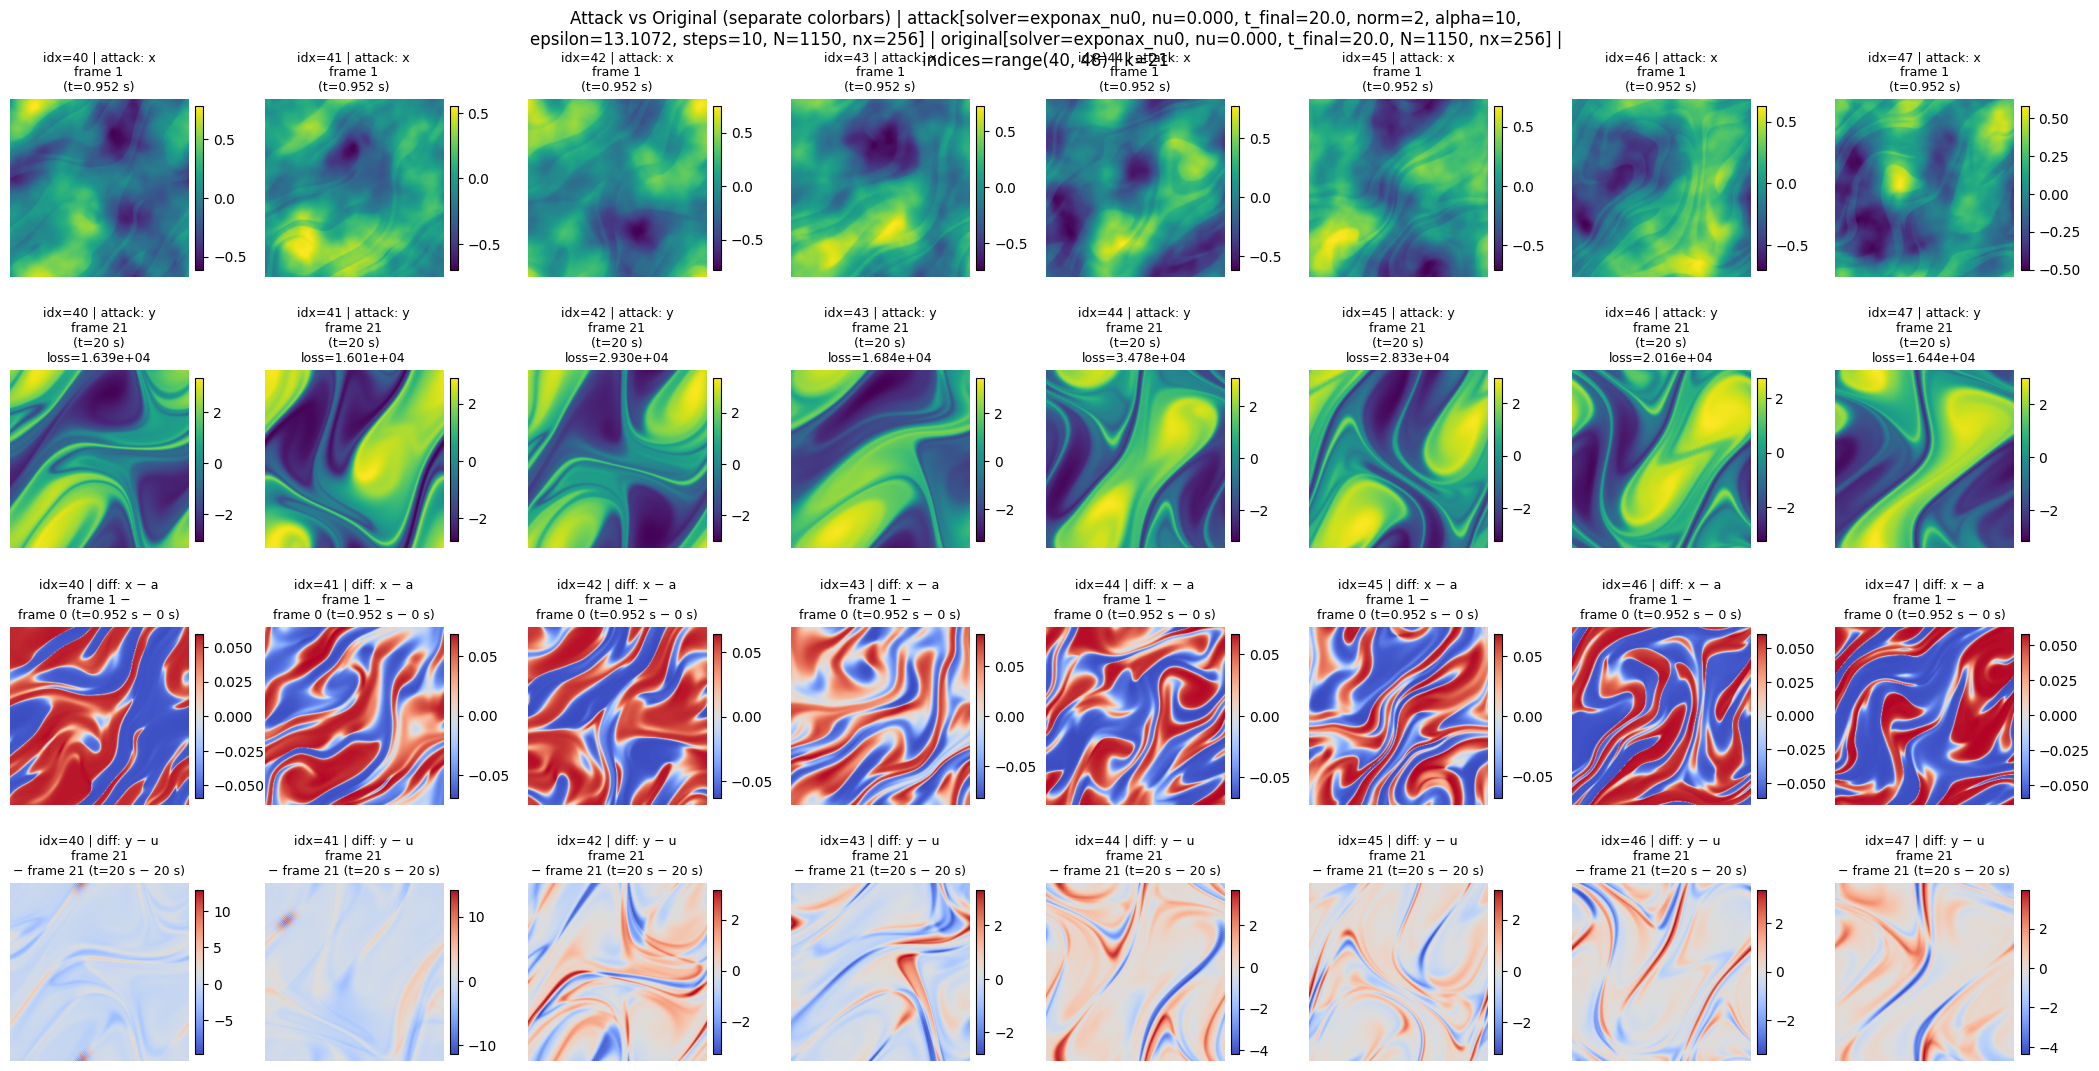

In [17]:
idxs = range(40,48)   # 8 个 index
fig, axes = plot_xy_compare_attack_original_indices(
    pt_attack, pt_orig, idx_list=idxs, t_idx=-1,
    cmap_attack="viridis", cmap_diff="coolwarm",)
plt.show()

/tmp/ipykernel_1764251/3848171066.py:194: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


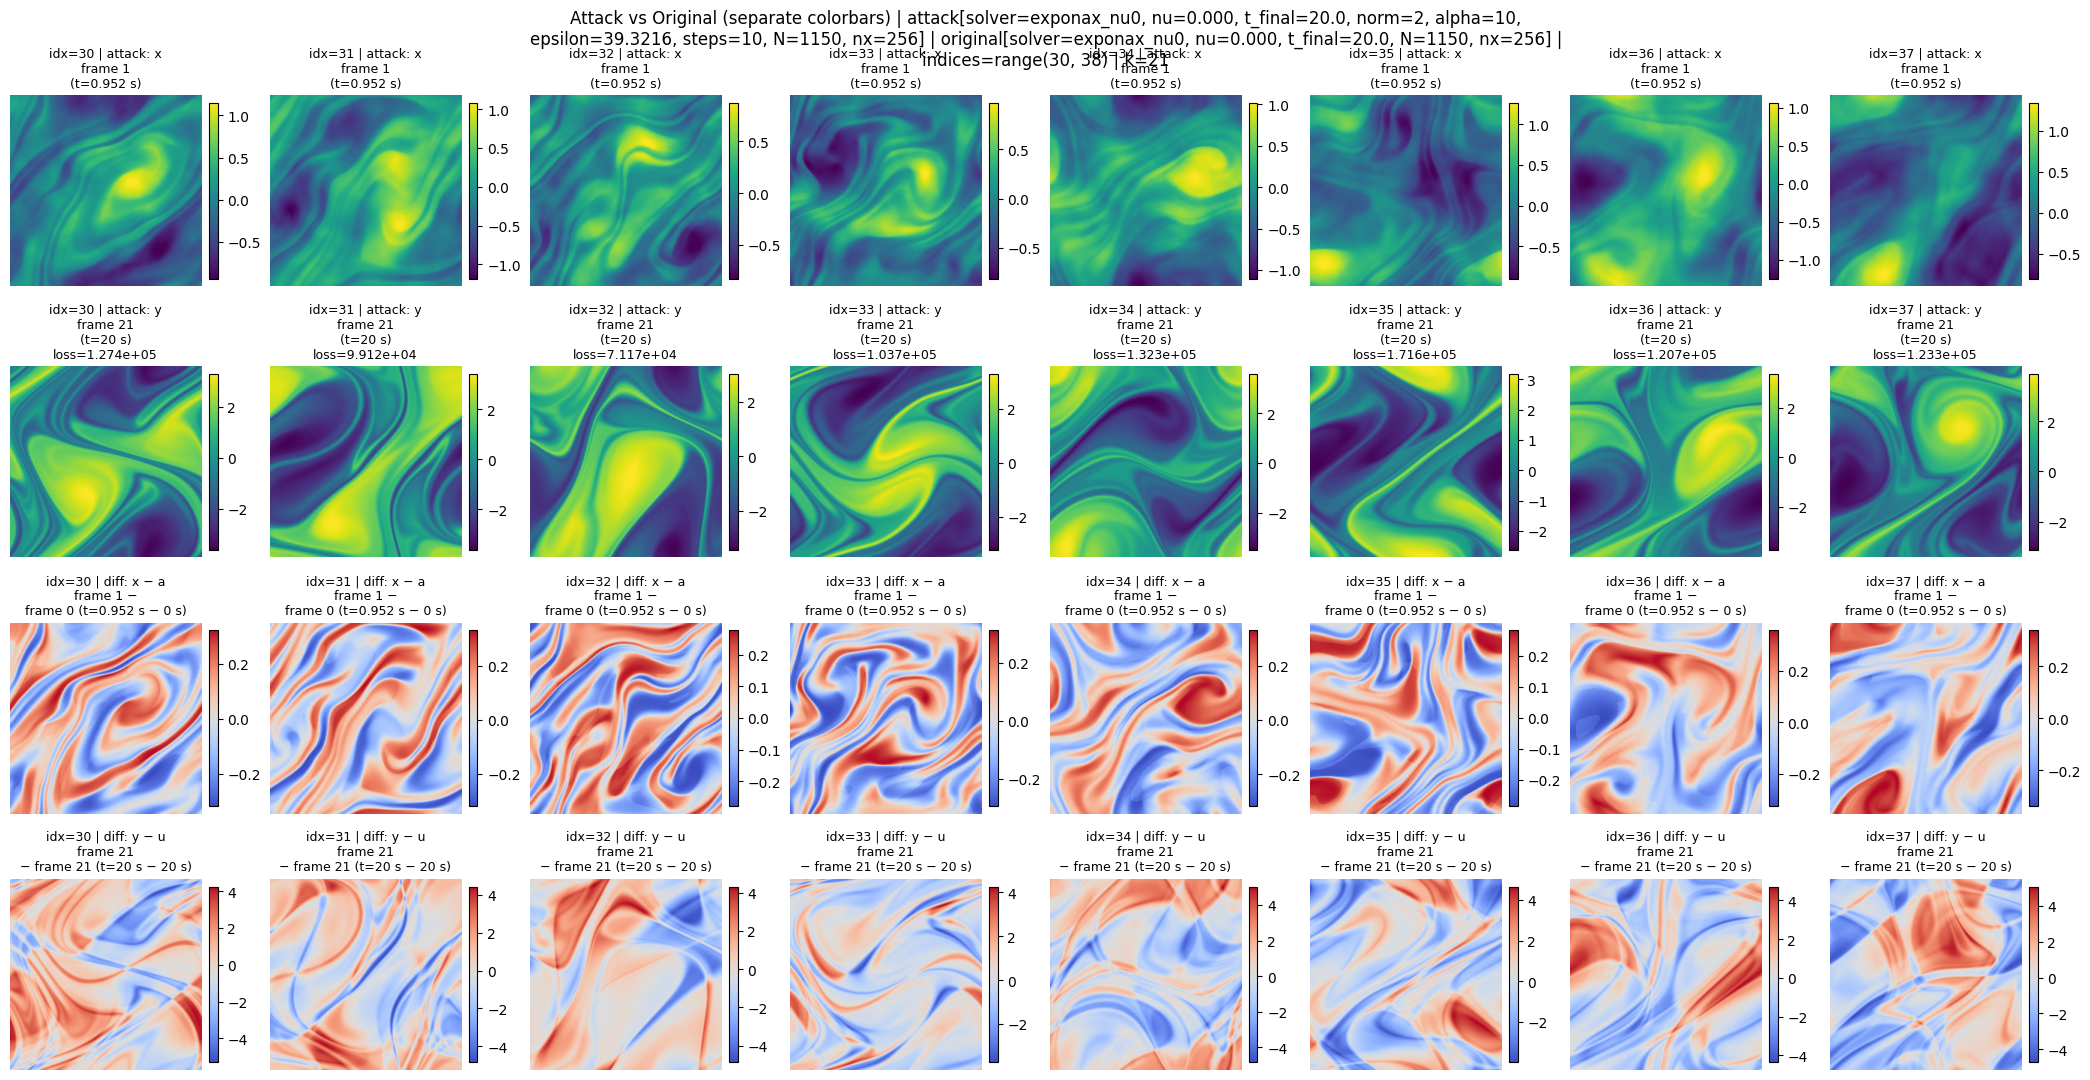

In [6]:
# pt_attack = "dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha50_epsilon39.3216_steps10.pt"
pt_attack = "dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames_modespec=wwwwwwwwww_norm2_alpha10_epsilon39.3216_steps10.pt"

pt_orig   = "../../../exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt"

idxs = range(30,38)   # 8 个 index
fig, axes = plot_xy_compare_attack_original_indices(
    pt_attack, pt_orig, idx_list=idxs, t_idx=-1,
    cmap_attack="viridis", cmap_diff="coolwarm",)
plt.show()

/tmp/ipykernel_1764251/3848171066.py:194: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


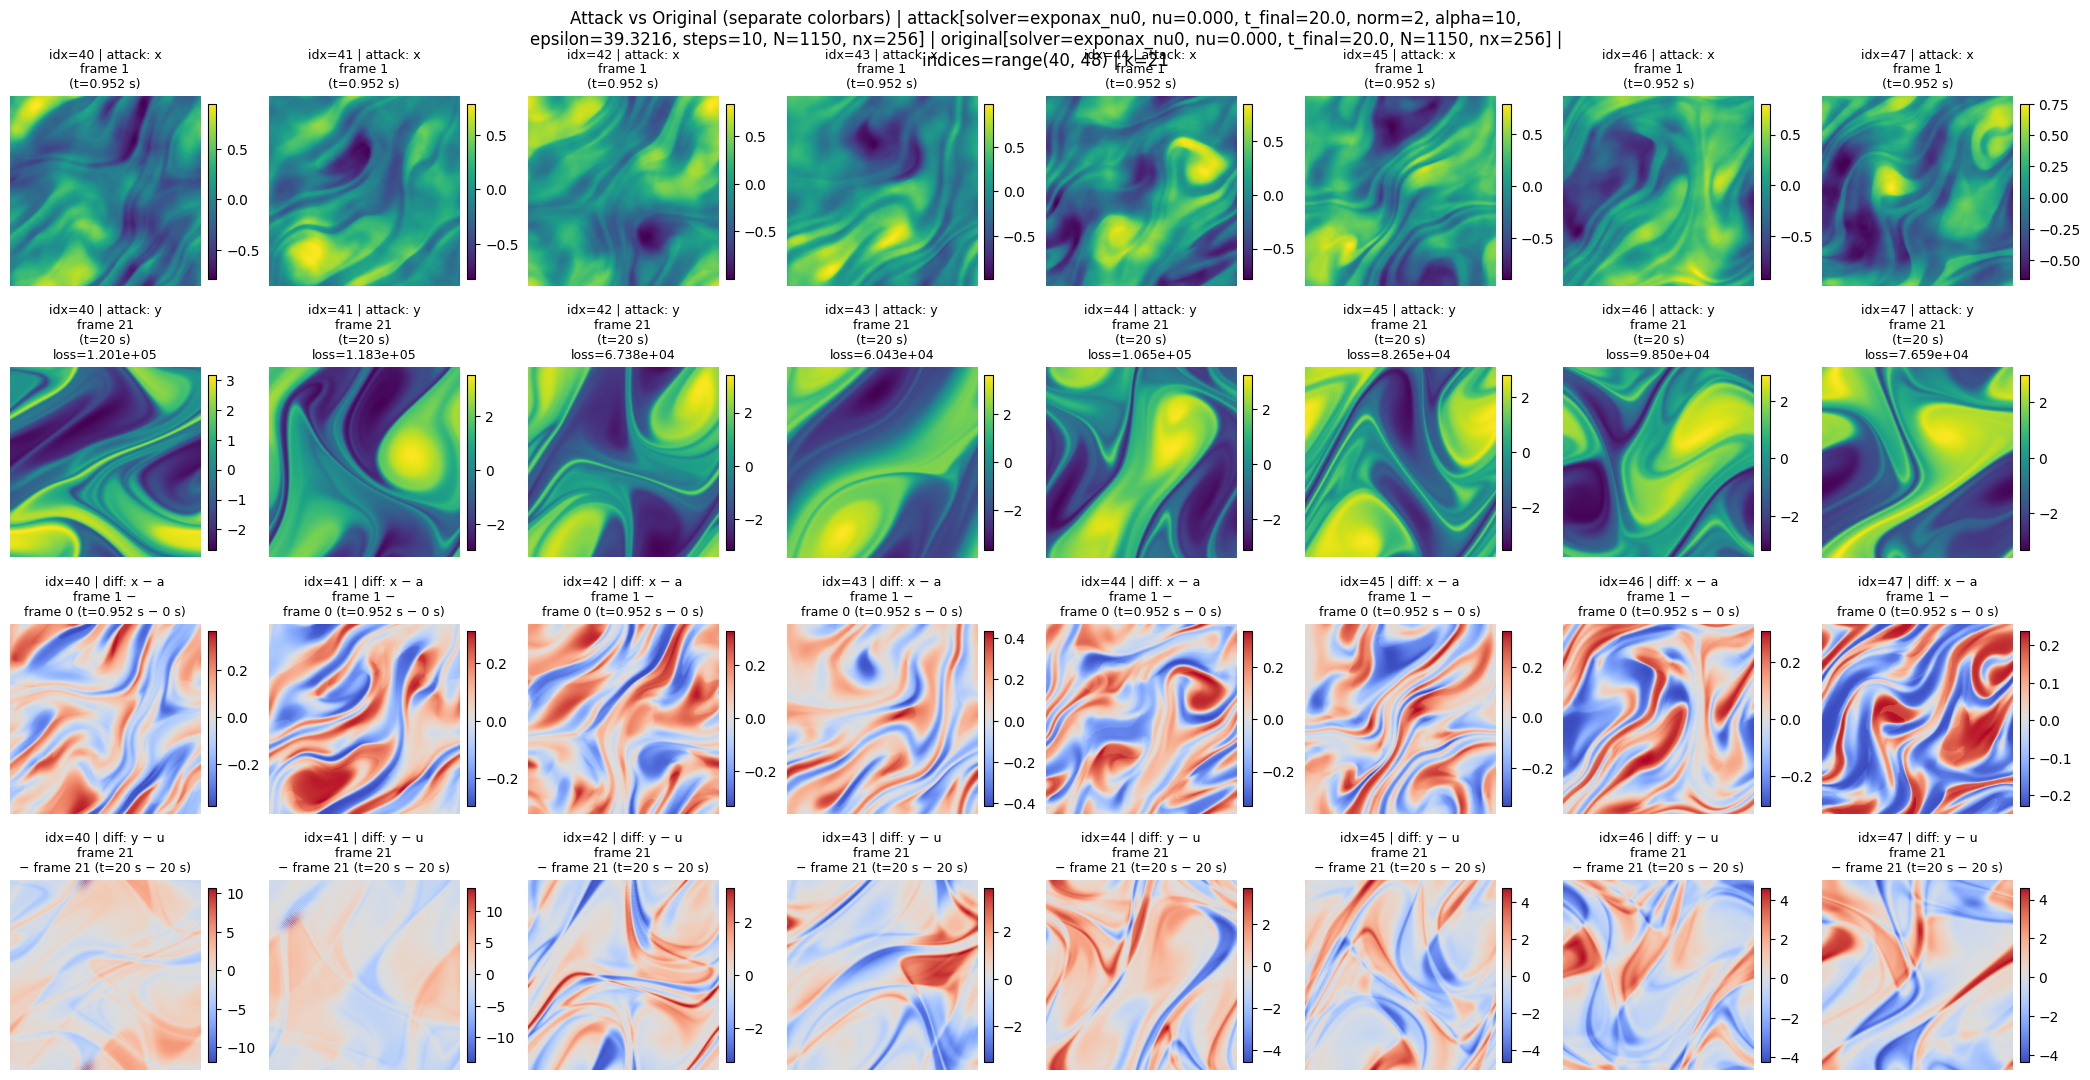

In [7]:
idxs = range(40,48)   # 8 个 index
fig, axes = plot_xy_compare_attack_original_indices(
    pt_attack, pt_orig, idx_list=idxs, t_idx=-1,
    cmap_attack="viridis", cmap_diff="coolwarm",)
plt.show()